# WL-AKSVD Interpretability Pipeline
Load data → train → interpret → visualise.

In [ ]:
import warnings
import numpy as np
import networkx as nx
from collections import Counter, defaultdict
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MaxAbsScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import display
from PIL import Image
import io

from graph_encoders.wl import WL
from dict_learners.aksvd import AKSVD
from utils.graph_data import GraphDataLoader
from interpreter.wl_aksvd_interpreter import WLAKSVDInterpreter

warnings.filterwarnings('ignore')

Imports OK


## 1 · Load the NCI dataset

In [2]:
data_loader = GraphDataLoader()
graphs, y, smiles = data_loader.nci_full_graphs, data_loader.nci_full_labels, data_loader.nci_full_smiles

print(f'Total graphs : {len(graphs)}')
print(f'Label dist.  : {Counter(y)}')

Loading NCI dataset


[16:00:56] Explicit valence for atom # 1 Cl, 1, is greater than permitted
[16:00:56] ERROR: Could not sanitize molecule ending on line 5976
[16:00:56] ERROR: Explicit valence for atom # 1 Cl, 1, is greater than permitted
[16:00:56] Explicit valence for atom # 0 Br, 1, is greater than permitted
[16:00:56] ERROR: Could not sanitize molecule ending on line 9488
[16:00:56] ERROR: Explicit valence for atom # 0 Br, 1, is greater than permitted
[16:00:56] Explicit valence for atom # 1 Cl, 1, is greater than permitted
[16:00:56] ERROR: Could not sanitize molecule ending on line 12926
[16:00:56] ERROR: Explicit valence for atom # 1 Cl, 1, is greater than permitted
[16:00:56] Explicit valence for atom # 1 Cl, 1, is greater than permitted
[16:00:56] ERROR: Could not sanitize molecule ending on line 13981
[16:00:56] ERROR: Explicit valence for atom # 1 Cl, 1, is greater than permitted
[16:00:56] Explicit valence for atom # 1 Cl, 1, is greater than permitted
[16:00:56] ERROR: Could not sanitize mol

Loaded 36937 graphs
Total graphs : 36937
Label dist.  : Counter({-1: 35203, 1: 1734})


## 2 · Train the pipeline

In [3]:
G_train, G_test, y_train, y_test = train_test_split(
    graphs, y, test_size=0.2, random_state=42
)
G_vocab_train, G_ML_train, y_vocab_train, y_ML_train = train_test_split(
    G_train, y_train, test_size=0.75, random_state=42
)
print(f'Vocab train : {len(G_vocab_train)}')
print(f'ML train    : {len(G_ML_train)}')
print(f'Test        : {len(G_test)}')

wl = WL()
wl_embeddings_vocab = wl.generate_training_embeddings(G_vocab_train, y_vocab_train)
print(f'\nVocab size  : {wl.n_vocab}')

aksvd = AKSVD()
aksvd.fit(training_graph_embeddings=wl_embeddings_vocab)
print(f'Dictionary  : {aksvd._dictionary.shape}')

X_ML_train = aksvd.infer(wl.generate_inferencing_embeddings(G_ML_train))
X_ML_test  = aksvd.infer(wl.generate_inferencing_embeddings(G_test))

scaler        = MaxAbsScaler()
X_ML_train_sc = scaler.fit_transform(X_ML_train)
X_ML_test_sc  = scaler.transform(X_ML_test)
print('Scaling done')

Vocab train : 7387
ML train    : 22162
Test        : 7388
Selected 6690 features via adaptive selection

Vocab size  : 6690
Dictionary  : (1024, 6690)
Scaling done


## 3 · Fit classifier

In [4]:
classifier = LogisticRegression(
    max_iter=1000, solver='saga', random_state=42, class_weight='balanced'
)
classifier.fit(X_ML_train_sc, y_ML_train)

y_pred = classifier.predict(X_ML_test_sc)
print(classification_report(y_test, y_pred))
print(f'Test accuracy: {accuracy_score(y_test, y_pred):.4f}')

              precision    recall  f1-score   support

          -1       0.98      0.85      0.91      7027
           1       0.19      0.68      0.30       361

    accuracy                           0.84      7388
   macro avg       0.59      0.77      0.60      7388
weighted avg       0.94      0.84      0.88      7388

Test accuracy: 0.8423


## 4 · Build interpreter

In [ ]:
LABEL_MAP = {-1: 'Inactive', 1: 'Active'}

interpreter = WLAKSVDInterpreter(
    wl=wl,
    aksvd=aksvd,
    classifier=classifier,
    scaler=scaler,
    training_graphs=G_ML_train,
    training_labels=list(y_ML_train),
    training_sparse_codes=X_ML_train,
    label_map=LABEL_MAP,
)

Interpreter ready


## 5 · SMILES → NetworkX graph converter

The converter auto-detects which node attribute format the training data uses,
then tries **both** candidate encodings (element symbol vs atomic number) and
keeps whichever gives the most vocabulary matches.  The final `✅ / ⚠️` line
confirms the result before you run any molecule.

In [6]:
# ── Step 1: Detect attribute KEY from G_ML_train (never from `graphs`,
# which may be overwritten by other cells).  G_ML_train always holds the
# exact objects that WL was trained on.
_sample_node = list(G_ML_train[0].nodes(data=True))[0][1]
_KEY = list(_sample_node.keys())[0]      # e.g. 'feature' or 'label'
_SAMPLE_VAL = list(_sample_node.values())[0]

print(f'Training node  →  key={_KEY!r}  sample_val={_SAMPLE_VAL!r}')


# ── Step 2: Define the two candidate VALUE functions ─────────────────────────
def _feat_symbol(atom):     return atom.GetSymbol()          # 'C', 'N', 'O'
def _feat_atomicnum(atom):  return str(atom.GetAtomicNum())  # '6', '7', '8'


# ── Step 3: Graph builder (parameterised) ─────────────────────────────────────
def _build_graph(smiles: str, key: str, feat_fn) -> nx.Graph:
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f'Cannot parse SMILES: {smiles!r}')
    g = nx.Graph()
    for atom in mol.GetAtoms():
        g.add_node(atom.GetIdx(), **{key: feat_fn(atom)})
    for bond in mol.GetBonds():
        g.add_edge(bond.GetBeginAtomIdx(), bond.GetEndAtomIdx())
    return g


# ── Step 4: Count vocabulary hits for a probe molecule ───────────────────────
# Phenol (Oc1ccccc1) contains both C and O so it exercises heteroatom encoding.
_PROBE   = 'Oc1ccccc1'
_vocab_s = {w for w, _ in wl.vocab}

def _hits(feat_fn):
    g   = _build_graph(_PROBE, _KEY, feat_fn)
    doc = wl.create_wl_hash([g])[0]
    return sum(1 for tok in doc.words if tok in _vocab_s)

_h_sym = _hits(_feat_symbol)
_h_num = _hits(_feat_atomicnum)

print(f'  symbol format  (C/N/O)  → {_h_sym} vocab hits on probe')
print(f'  atomic-num fmt (6/7/8)  → {_h_num} vocab hits on probe')


# ── Step 5: Choose the better encoding ────────────────────────────────────────
if _h_sym == 0 and _h_num == 0:
    # Neither attributed format works → WL is falling back to degree-based
    # features.  This can happen when karateclub's API changed between versions
    # and `attributed=True` is no longer being respected.  The node attribute
    # does not affect tokenisation, so any consistent choice is fine.
    _FEAT_FN = _feat_symbol
    print(
        '\n⚠️  Both encodings give 0 matches for the probe molecule.'
        '\n   WL is most likely running in degree-only mode (no attribute used).'
        '\n   Node attribute encoding does not affect tokenisation in this mode.'
        '\n   If active atoms remain 0 for all SMILES, consider retraining with'
        '\n   a fixed WL attribute name (see wl.py → create_wl_hash).'
    )
elif _h_sym >= _h_num:
    _FEAT_FN = _feat_symbol
    print(f'\n✅ Using element SYMBOL encoding  ({_h_sym} hits ≥ {_h_num})')
else:
    _FEAT_FN = _feat_atomicnum
    print(f'\n✅ Using ATOMIC NUMBER encoding  ({_h_num} hits > {_h_sym})')


# ── Step 6: Expose clean public API ──────────────────────────────────────────
def smiles_to_graph(smiles: str) -> nx.Graph:
    """Convert SMILES to a NetworkX graph matching the WL training format."""
    return _build_graph(smiles, _KEY, _FEAT_FN)


def smiles_to_mol_and_graph(smiles: str):
    """Return (RDKit Mol, NetworkX graph) for a SMILES string."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f'Cannot parse SMILES: {smiles!r}')
    return mol, smiles_to_graph(smiles)

Training node  →  key='feature'  sample_val='Cl'
  symbol format  (C/N/O)  → 14 vocab hits on probe
  atomic-num fmt (6/7/8)  → 0 vocab hits on probe

✅ Using element SYMBOL encoding  (14 hits ≥ 0)


## 6 · Visualisation helpers

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import hashlib
import networkx as nx
from collections import defaultdict
import pandas as pd

# ─────────────────────────────────────────────────────────────────────────────
# WL token descriptions + substructure membership
# ─────────────────────────────────────────────────────────────────────────────

_ATOMIC_SYMBOLS = {
    '1':'H',  '5':'B',  '6':'C',  '7':'N',  '8':'O',  '9':'F',
    '14':'Si','15':'P', '16':'S', '17':'Cl','33':'As','34':'Se',
    '35':'Br','53':'I',
}

def _readable_label(s):
    if s in _ATOMIC_SYMBOLS:
        return _ATOMIC_SYMBOLS[s]
    if len(s) == 32 and all(c in '0123456789abcdef' for c in s):
        return f'[{s[:6]}..]'
    return s


def _build_wl_token_map(graph, attr_key, wl_iterations=2):
    nodes = list(graph.nodes())
    features = {}
    for node in nodes:
        attrs = dict(graph.nodes[node])
        val = str(attrs.get(attr_key, graph.degree(node))) if attr_key else str(graph.degree(node))
        features[node] = val
    base_desc = {val: _readable_label(val) for val in features.values()}

    token_desc    = {}
    token_members = defaultdict(list)

    for it in range(wl_iterations):
        radius = it + 1
        new_features = {}
        for node in nodes:
            nbr_feats = sorted(features[n] for n in graph.neighbors(node))
            parts     = [features[node]] + nbr_feats
            token     = hashlib.md5('_'.join(parts).encode()).hexdigest()
            new_features[node] = token

            subtree = set(nx.single_source_shortest_path_length(graph, node, cutoff=radius))
            token_members[token].append(subtree)

            if token not in token_desc:
                if it == 0:
                    readable = [base_desc.get(p, _readable_label(p)) for p in parts]
                    token_desc[token] = '_'.join(readable)
                else:
                    readable = [token_desc.get(p, p[:6]+'..') for p in parts]
                    desc = readable[0] + '*(' + ','.join(readable[1:]) + ')'
                    token_desc[token] = desc[:45]+'..' if len(desc) > 45 else desc
        features = new_features

    return token_desc, token_members


# ─────────────────────────────────────────────────────────────────────────────
# Colour helpers
# ─────────────────────────────────────────────────────────────────────────────

def _build_token_colour_map(sorted_tokens, top_n, floor=0.35):
    sup_cm = matplotlib.colormaps['Reds']
    opp_cm = matplotlib.colormaps['Blues']
    supporting = [(t, s) for t, s in sorted_tokens if s > 0][:top_n]
    opposing   = [(t, s) for t, s in sorted_tokens if s < 0][:top_n]
    colours = {}
    if supporting:
        max_s = max(abs(s) for _, s in supporting)
        for tok, score in supporting:
            colours[tok] = sup_cm(floor + (abs(score)/max_s)*(1-floor))
    if opposing:
        max_o = max(abs(s) for _, s in opposing)
        for tok, score in opposing:
            colours[tok] = opp_cm(floor + (abs(score)/max_o)*(1-floor))
    return colours


def _expand_to_atoms(token_colour_map, token_members, sorted_tokens):
    atom_colours = {}
    for tok, _ in sorted_tokens:
        if tok not in token_colour_map:
            continue
        colour = token_colour_map[tok]
        for occurrence in token_members.get(tok, []):
            for atom_idx in occurrence:
                atom_colours.setdefault(atom_idx, colour)
    return atom_colours


def _truncated_cmap(name, lo=0.35, hi=1.0, n=256):
    """Return a colormap restricted to the [lo, hi] intensity band."""
    return mcolors.LinearSegmentedColormap.from_list(
        f'{name}_trunc',
        matplotlib.colormaps[name](np.linspace(lo, hi, n)),
    )


def _show_with_colourbar(img, sorted_tokens, top_n, title="", floor=0.35):
    """
    Display molecule image with Red/Blue colour bars whose ticks show
    actual score values.  Only bars for directions that are present are drawn.
    """
    supporting = [(t, s) for t, s in sorted_tokens if s > 0][:top_n]
    opposing   = [(t, s) for t, s in sorted_tokens if s < 0][:top_n]

    n_bars = (1 if supporting else 0) + (1 if opposing else 0)
    w, h   = img.size
    ratios = [w] + [30] * n_bars

    fig, axes = plt.subplots(
        1, 1 + n_bars,
        figsize=(w / 96 + n_bars * 1.4, h / 96),
        gridspec_kw={'width_ratios': ratios},
    )
    if not isinstance(axes, np.ndarray):
        axes = [axes]

    axes[0].imshow(img)
    axes[0].axis('off')
    if title:
        axes[0].set_title(title, fontsize=10, pad=6)

    bar_idx = 1

    if supporting:
        abs_scores = sorted(abs(s) for _, s in supporting)
        vmin = abs_scores[0] if abs_scores[0] != abs_scores[-1] else 0.0
        vmax = abs_scores[-1]
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
        cb = plt.colorbar(
            plt.cm.ScalarMappable(norm=norm, cmap=_truncated_cmap('Reds', lo=floor)),
            cax=axes[bar_idx],
        )
        cb.set_label('Score  (supporting ▲)', fontsize=8, labelpad=6)
        cb.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.3f}'))
        cb.ax.tick_params(labelsize=7)
        bar_idx += 1

    if opposing:
        abs_scores = sorted(abs(s) for _, s in opposing)
        vmin = abs_scores[0] if abs_scores[0] != abs_scores[-1] else 0.0
        vmax = abs_scores[-1]
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
        cb = plt.colorbar(
            plt.cm.ScalarMappable(norm=norm, cmap=_truncated_cmap('Blues', lo=floor)),
            cax=axes[bar_idx],
        )
        cb.set_label('|Score|  (opposing ▼)', fontsize=8, labelpad=6)
        cb.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.3f}'))
        cb.ax.tick_params(labelsize=7)

    plt.tight_layout(pad=0.5)
    plt.show()


def _render_molecule(mol, colour_map, img_size):
    h_atoms = list(colour_map)
    h_aclrs = {int(k): tuple(v[:3]) for k, v in colour_map.items()}
    h_bonds, h_bclrs = [], {}
    for bond in mol.GetBonds():
        a1, a2 = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        if a1 in colour_map and a2 in colour_map and colour_map[a1] == colour_map[a2]:
            bid = bond.GetIdx()
            h_bonds.append(bid)
            h_bclrs[bid] = tuple(colour_map[a1][:3])
    drawer = rdMolDraw2D.MolDraw2DCairo(*img_size)
    drawer.drawOptions().useBWAtomPalette()
    drawer.DrawMolecule(
        mol,
        highlightAtoms=h_atoms, highlightAtomColors=h_aclrs,
        highlightBonds=h_bonds, highlightBondColors=h_bclrs,
    )
    drawer.FinishDrawing()
    return Image.open(io.BytesIO(drawer.GetDrawingText()))


# ─────────────────────────────────────────────────────────────────────────────
# Public functions
# ─────────────────────────────────────────────────────────────────────────────

def visualise_subtrees(smiles, interpreter, top_n=5, img_size=(600, 400), debug=False):
    """
    Token-based subtree highlighting.

    Score A  =  atom_contribution x dictionary_weight
    Score B  =  atom_contribution x dictionary_weight x wl_feature_count

    Displays two feature tables then two images each with a score colour bar.
    Every occurrence of each top-N token's substructure is highlighted.
    Red = promotes prediction, Blue = opposes (darker = higher score).
    """
    mol, graph = smiles_to_mol_and_graph(smiles)
    result     = interpreter.get_node_importance(graph, top_k_atoms=5)
    AllChem.Compute2DCoords(mol)

    vocab_index = {w: i for i, w in enumerate(interpreter.vocab_words)}
    wl_emb = interpreter.wl.generate_inferencing_embeddings([graph])
    wl_vec = wl_emb[0]

    feat_a = defaultdict(float)
    feat_b = defaultdict(float)
    seen   = set()
    for sources in result['node_sources'].values():
        for src in sources:
            key = (src['atom_idx'], src['token'])
            if key in seen:
                continue
            seen.add(key)
            pa = src.get('path_importance_a', src.get('path_importance', 0.0))
            pb = src.get('path_importance_b', None)
            if pb is None:
                fi = vocab_index.get(src['token'])
                pb = pa * float(wl_vec[fi]) if fi is not None else pa
            feat_a[src['token']] += pa
            feat_b[src['token']] += pb

    sorted_tok_a = sorted(feat_a.items(), key=lambda x: abs(x[1]), reverse=True)
    sorted_tok_b = sorted(feat_b.items(), key=lambda x: abs(x[1]), reverse=True)

    g        = interpreter.wl._check_graph(graph)
    _attrs   = dict(list(g.nodes(data=True))[0][1])
    attr_key = list(_attrs.keys())[0] if _attrs else None
    token_desc, token_members = _build_wl_token_map(g, attr_key, wl_iterations=2)

    def _make_table(feat_scores, score_col):
        if not feat_scores:
            return pd.DataFrame()
        total  = sum(abs(v) for v in feat_scores.values()) or 1.0
        ranked = sorted(feat_scores.items(), key=lambda x: abs(x[1]), reverse=True)
        rows = []
        for word, score in [(w,s) for w,s in ranked if s>0][:top_n] + \
                           [(w,s) for w,s in ranked if s<0][:top_n]:
            fi = vocab_index.get(word)
            if fi is None:
                continue
            info = interpreter.explain_wl_feature(fi)
            prev = " | ".join(
                f"{cls}: {st['prevalence_pct']:.1f}%"
                for cls, st in info['class_statistics'].items()
            )
            rows.append({
                'Dir':              'Supp.' if score > 0 else 'Oppos.',
                score_col:          round(score, 5),
                '% Total':          f"{abs(score)/total*100:.1f}%",
                'WL Description':   token_desc.get(word, word[:14]+'..'),
                'Occurrences':      len(token_members.get(word, [])),
                'Dominant Class':   info['dominant_class'],
                'Class Prevalence': prev,
                'Disc. Score':      round(info['discriminative_score'], 5),
            })
        return pd.DataFrame(rows)

    sep = '-' * 68
    print(sep)
    print('  FEATURE TABLE  Score A  =  atom_contribution x dict_weight')
    print(sep)
    display(_make_table(feat_a, 'Score A'))
    print()
    print(sep)
    print('  FEATURE TABLE  Score B  =  Score A x wl_feature_count')
    print(sep)
    display(_make_table(feat_b, 'Score B'))

    tok_cm_a = _build_token_colour_map(sorted_tok_a, top_n)
    tok_cm_b = _build_token_colour_map(sorted_tok_b, top_n)
    cm_a = _expand_to_atoms(tok_cm_a, token_members, sorted_tok_a)
    cm_b = _expand_to_atoms(tok_cm_b, token_members, sorted_tok_b)

    if debug:
        print(f'\n[DEBUG] RDKit atoms: {mol.GetNumAtoms()}')
        for tok, sc in sorted_tok_a[:8]:
            n_occ = len(token_members.get(tok, []))
            print(f'  {token_desc.get(tok, tok[:12]):<40}  score={sc:+.4f}  occ={n_occ}')

    img_a = _render_molecule(mol, cm_a, img_size)
    img_b = _render_molecule(mol, cm_b, img_size)
    _show_with_colourbar(img_a, sorted_tok_a, top_n,
                         title="Score A  (atom_contribution × dict_weight)")
    _show_with_colourbar(img_b, sorted_tok_b, top_n,
                         title="Score B  (Score A × wl_feature_count)")
    return img_a, img_b


def visualise_prediction(smiles, interpreter, top_k_atoms=5, img_size=(600, 400),
                         show_percentages=True):
    """Full-molecule per-atom highlight using Score A."""
    mol, graph = smiles_to_mol_and_graph(smiles)
    result     = interpreter.get_node_importance(graph, top_k_atoms=top_k_atoms)
    AllChem.Compute2DCoords(mol)
    colour_map = {}
    if result['sorted_nodes']:
        max_abs = max(abs(s) for _, s in result['sorted_nodes']) or 1.0
        for nid, score in result['sorted_nodes']:
            mapped = 0.15 + (abs(score)/max_abs)*0.85
            colour_map[nid] = (matplotlib.colormaps['Reds'](mapped)
                               if score >= 0 else
                               matplotlib.colormaps['Blues'](mapped))
    if show_percentages:
        for atom in mol.GetAtoms():
            idx = atom.GetIdx()
            if idx in result['node_importance_pct']:
                atom.SetProp('atomNote', f"{result['node_importance_pct'][idx]:.1f}%")
    img = _render_molecule(mol, colour_map, img_size)
    _show_with_colourbar(img, result['sorted_nodes'],
                         top_n=len(result['sorted_nodes']),
                         title="Full molecule  (Score A, all atoms)", floor=0.15)
    return img


def full_analysis(smiles, interpreter, top_k_atoms=5, top_n_subtrees=5, img_size=(700, 450)):
    """Text report + full-molecule view + dual token-based subtree images."""
    _, graph = smiles_to_mol_and_graph(smiles)
    print(interpreter.full_report(graph, top_k_atoms=top_k_atoms, top_k_features_per_atom=5))

    print('\n-- FULL MOLECULE  (red = promoting | blue = opposing) --')
    display(visualise_prediction(smiles, interpreter, top_k_atoms=top_k_atoms, img_size=img_size))

    img_a, img_b = visualise_subtrees(smiles, interpreter,
                                      top_n=top_n_subtrees, img_size=img_size)
    print(f'\n-- SUBTREE HIGHLIGHTS (top {top_n_subtrees} tokens per direction, all occurrences) --')
    print('  Score A: atom_contribution x dictionary_weight')
    display(img_a)
    print('  Score B: atom_contribution x dictionary_weight x wl_feature_count')
    display(img_b)


print('Visualisation helpers ready (token-based, 2-iteration WL)')

Visualisation helpers ready (token-based, 2-iteration WL)


## 7 · Analyse a single molecule

  PREDICTION   : Active
  CONFIDENCE   : 90.1%
  ACTIVE ATOMS : 10
  CONTRIBUTION BREAKDOWN          [S = Supporting | O = Opposing]
  Dictionary Atom            Bar                                   %
-----------------------------------------------------------------
  Dict Atom  762 [S]         ███████░░░░░░░░░░░░░░░░░░░░░░░   22.7%
  Dict Atom 1022 [S]         ███████░░░░░░░░░░░░░░░░░░░░░░░   22.2%
  Dict Atom  866 [S]         ██████░░░░░░░░░░░░░░░░░░░░░░░░   19.0%
  Dict Atom 1023 [S]         ████░░░░░░░░░░░░░░░░░░░░░░░░░░   12.9%
  Dict Atom 1007 [S]         ██░░░░░░░░░░░░░░░░░░░░░░░░░░░░    7.2%
  Others                     █████░░░░░░░░░░░░░░░░░░░░░░░░░   16.0%

-- LEVEL 1: Prediction Reasoning --
  Prediction : Active  (Confidence: 90.1%)
  Atoms driving this prediction:
    * Dict Atom  762   22.7%  [supporting]  activation=1.6192
    * Dict Atom 1022   22.2%  [supporting]  activation=6.7628
    * Dict Atom  866   19.0%  [supporting]  activation=2.4498
    * Dict Atom 1023   12

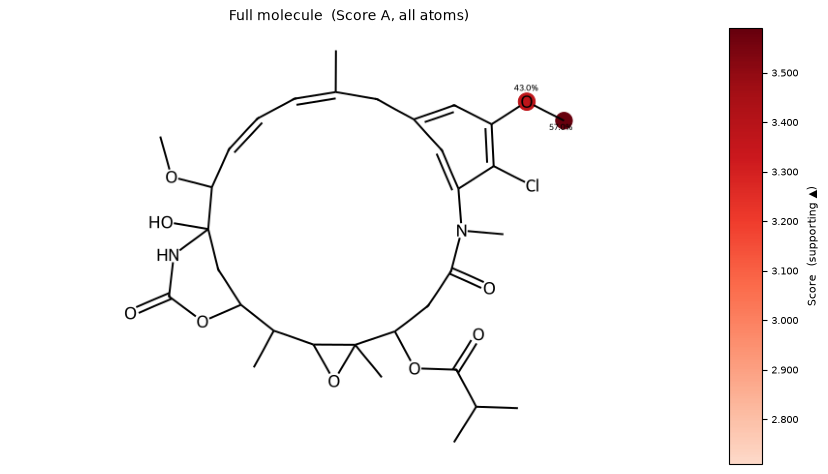

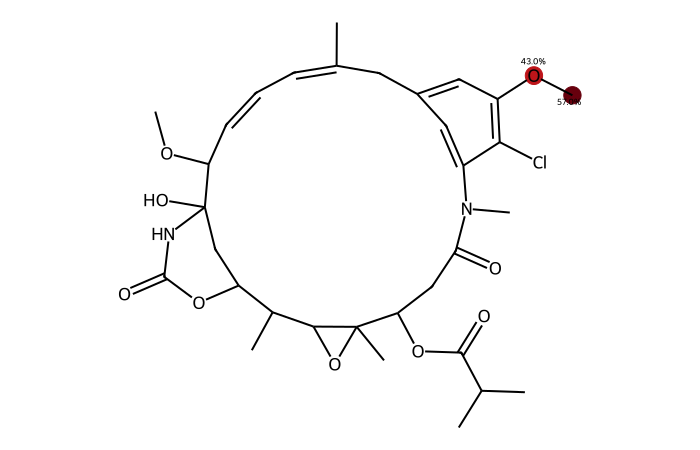

--------------------------------------------------------------------
  FEATURE TABLE  Score A  =  atom_contribution x dict_weight
--------------------------------------------------------------------


,Dir,Score A,% Total,WL Description,Occurrences,Dominant Class,Class Prevalence,Disc. Score
0,Supp.,0.67310,8.7%,O_C_O,4,Active,Inactive: 77.5% | Active: 79.5%,0.00884
1,Supp.,0.62673,8.1%,"C_C_C*(C_C_C_C_C,C_C_C)",4,Active,Inactive: 19.1% | Active: 31.1%,0.03023
2,Supp.,0.60859,7.8%,C_C_C_C_N_O,1,Inactive,Inactive: 0.9% | Active: 0.6%,0.00016
3,Supp.,0.52362,6.7%,C_C_C,5,Active,Inactive: 51.3% | Active: 65.4%,0.05381
4,Supp.,0.47581,6.1%,"C_C_C_C_C*(C_C_C_C_C,C_C_C_C,C_C_C_C,C_C_C)",1,Inactive,Inactive: 5.7% | Active: 5.6%,0.00011
5,Oppos.,-0.29220,3.8%,C_C_C_C_N,1,Inactive,Inactive: 64.1% | Active: 63.6%,0.00177
6,Oppos.,-0.09680,1.2%,"C_C_C_C*(C_C_C_C,C_C_C_C,C_C_C_C)",1,Inactive,Inactive: 59.6% | Active: 48.7%,0.04031
7,Oppos.,-0.09013,1.2%,"C_C_C_C*(C_C_C_C_C,C_C_C_C,C_C_C_C_N)",1,Active,Inactive: 11.7% | Active: 14.7%,0.00547
8,Oppos.,-0.07574,1.0%,"C_C_C_C_C*(C_C_C_C_C,C_C_C_C,C_C_C_C,C_C_C_C)",1,Inactive,Inactive: 11.7% | Active: 9.7%,0.00323
9,Oppos.,-0.07461,1.0%,N_C_C_N,1,Active,Inactive: 54.5% | Active: 57.5%,0.01130



--------------------------------------------------------------------
  FEATURE TABLE  Score B  =  Score A x wl_feature_count
--------------------------------------------------------------------


,Dir,Score B,% Total,WL Description,Occurrences,Dominant Class,Class Prevalence,Disc. Score
0,Supp.,2.69241,13.0%,O_C_O,4,Active,Inactive: 77.5% | Active: 79.5%,0.00884
1,Supp.,2.61810,12.6%,C_C_C,5,Active,Inactive: 51.3% | Active: 65.4%,0.05381
2,Supp.,2.50693,12.1%,"C_C_C*(C_C_C_C_C,C_C_C)",4,Active,Inactive: 19.1% | Active: 31.1%,0.03023
3,Supp.,2.43652,11.8%,C_C_C_C,8,Active,Inactive: 94.8% | Active: 96.8%,0.00991
4,Supp.,2.27877,11.0%,O_C_C_O,5,Active,Inactive: 50.5% | Active: 65.4%,0.05662
5,Oppos.,-0.29220,1.4%,C_C_C_C_N,1,Inactive,Inactive: 64.1% | Active: 63.6%,0.00177
6,Oppos.,-0.09680,0.5%,"C_C_C_C*(C_C_C_C,C_C_C_C,C_C_C_C)",1,Inactive,Inactive: 59.6% | Active: 48.7%,0.04031
7,Oppos.,-0.09013,0.4%,"C_C_C_C*(C_C_C_C_C,C_C_C_C,C_C_C_C_N)",1,Active,Inactive: 11.7% | Active: 14.7%,0.00547
8,Oppos.,-0.07574,0.4%,"C_C_C_C_C*(C_C_C_C_C,C_C_C_C,C_C_C_C,C_C_C_C)",1,Inactive,Inactive: 11.7% | Active: 9.7%,0.00323
9,Oppos.,-0.07461,0.4%,N_C_C_N,1,Active,Inactive: 54.5% | Active: 57.5%,0.01130


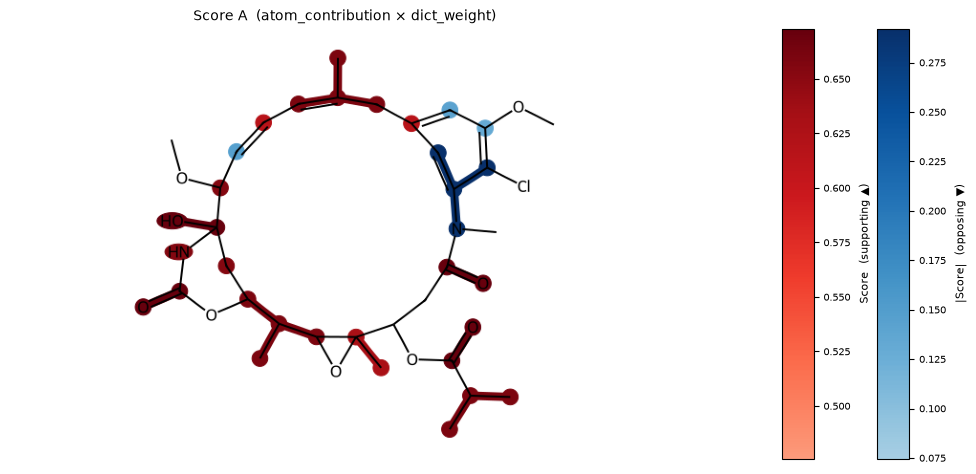

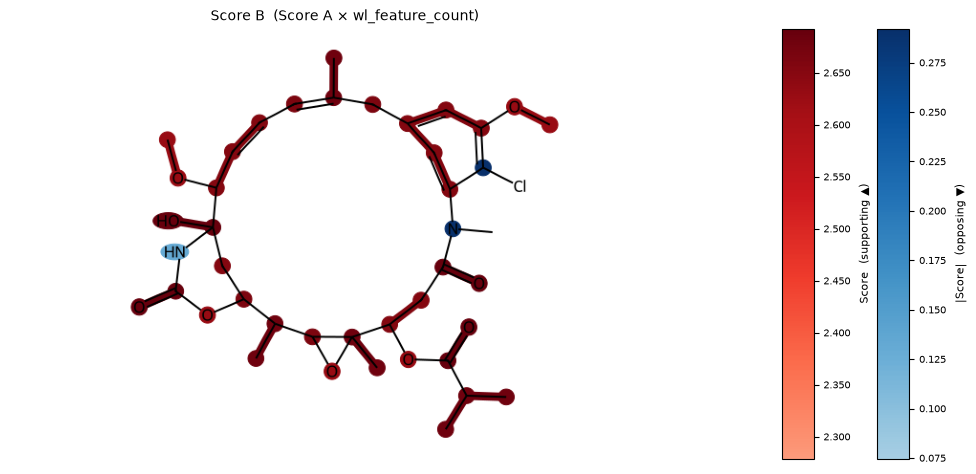


-- SUBTREE HIGHLIGHTS (top 5 tokens per direction, all occurrences) --
  Score A: atom_contribution x dictionary_weight


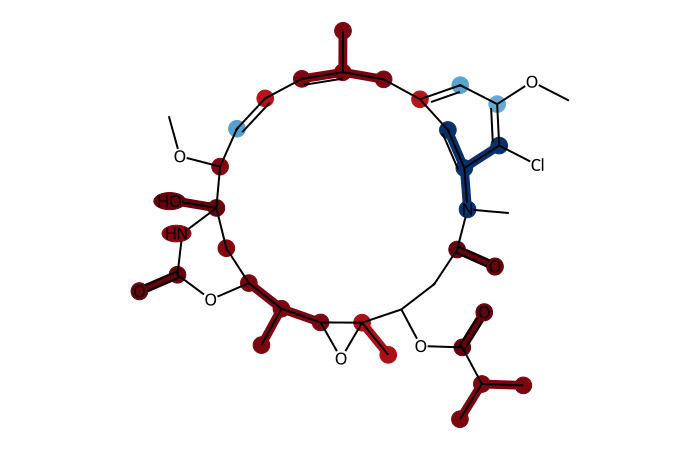

  Score B: atom_contribution x dictionary_weight x wl_feature_count


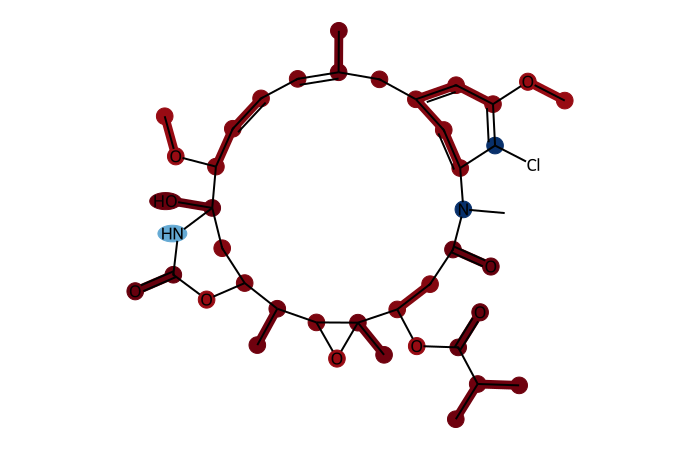

In [8]:
SMILES = 'COc1cc2cc(c1Cl)N(C)C(=O)CC(OC(=O)C(C)C)C1(C)OC1C(C)C1CC(O)(NC(=O)O1)C(OC)C=CC=C(C)C2'

full_analysis(SMILES, interpreter, top_k_atoms=5, top_n_subtrees=5)